In [21]:
# Read and print JSON or JSONL files from the tracked lab logs.

from pathlib import Path
import json


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
lab_root = repo_root / "src" / "project" / "logs" / "tracked" / "lab"
if not lab_root.exists():
    fallback = repo_root.parent / "src" / "project" / "logs" / "tracked" / "lab"
    lab_root = fallback if fallback.exists() else lab_root

files = sorted(lab_root.rglob("*_export.jsonl"))
if not files:
    files = sorted(lab_root.rglob("*_events.jsonl"))
if not files:
    raise FileNotFoundError(f"No export/event JSONL files found under {lab_root}")

for file_path in files[:3]:
    print(f"Reading: {file_path}")

    with file_path.open("r", encoding="utf-8") as f:
        data = [json.loads(line) for line in f if line.strip()]

    print("Loaded:", type(data).__name__, "rows:", len(data))
    print(data[:2])

Reading: C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\src\project\logs\tracked\lab\lab_subject_1\exp_20260721T091553Z_7b92ec42_export.jsonl
Loaded: list rows: 196
[{'experiment_id': 'exp_20260721T091553Z_7b92ec42', 'participant_id': '3568405d', 'conversation_id': '3568405d', 'timestamp': '2026-07-21T09:15:53.844850+00:00', 'unix_ts': 1784625353, 'event': 'session_started', 'source': 'system', 'step_index': 1, 'ad_mode': 'session', 'trial_index': 0, 'turn': 0, 'data': {'participant_id': '3568405d', 'study_type': 'lab', 'skip_screens': ['prolific_id', 'validation'], 'protocol': 'workflow_a_star', 'conditions': [{'condition': 'block_late', 'ad_mode': 'explicit_ad_block', 'ad_window': [4, 4], 'ad_turn': 4, 'task': {'id': 'swt_fitness_restart', 'title': 'Restart your fitness routine', 'genre': 'Social', 'participant_prompt': 'You want to become more active again after a long break, but your schedule is irregular and your motivation has been inconsistent in the past.\n

In [ ]:
# Create a CSV file with participant-by-condition scores from the tracked lab logs.
# The data are stored under src/project/logs/tracked/lab and are exported as *_export.jsonl files.

from pathlib import Path
import json
import csv
from collections import defaultdict


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
lab_root = repo_root / "src" / "project" / "logs" / "tracked" / "lab"
if not lab_root.exists():
    fallback = repo_root.parent / "src" / "project" / "logs" / "tracked" / "lab"
    lab_root = fallback if fallback.exists() else lab_root

files = sorted(lab_root.rglob("*_export.jsonl"))
if not files:
    files = sorted(lab_root.rglob("*_events.jsonl"))
if not files:
    raise FileNotFoundError(f"No export/event JSONL files found under {lab_root}")

scores = defaultdict(list)

for path in files:
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            if rec.get("event") != "post_condition_survey_submitted":
                continue

            data = rec.get("data", {})
            resp = data.get("responses", {})

            participant = rec.get("participant_id") or data.get("participant_id")
            condition = data.get("condition") or rec.get("condition") or "unknown"
            if not participant:
                continue

            def get(name):
                return resp.get(name)

            credibility = None
            llm_reliable = get("llm_reliable")
            llm_false = get("llm_false")
            llm_made_up = get("llm_made_up")
            if llm_reliable is not None and llm_false is not None and llm_made_up is not None:
                llm_false_inverse = 8 - llm_false
                llm_made_up_inverse = 8 - llm_made_up
                credibility = (llm_reliable + llm_false_inverse + llm_made_up_inverse) / 3

            helpfulness = None
            llm_helpful = get("llm_helpful")
            llm_addressed = get("llm_addressed")
            llm_not_aid = get("llm_not_aid")
            if llm_helpful is not None and llm_addressed is not None and llm_not_aid is not None:
                llm_not_aid_inverse = 8 - llm_not_aid
                helpfulness = (llm_helpful + llm_addressed + llm_not_aid_inverse) / 3

            convincingness = None
            llm_skeptical = get("llm_skeptical")
            llm_convincing = get("llm_convincing")
            llm_changed_mind = get("llm_changed_mind")
            if llm_skeptical is not None and llm_convincing is not None and llm_changed_mind is not None:
                llm_skeptical_inverse = 8 - llm_skeptical
                convincingness = (llm_skeptical_inverse + llm_convincing + llm_changed_mind) / 3

            relevance = None
            llm_not_useful = get("llm_not_useful")
            llm_suggestions = get("llm_suggestions")
            llm_relevant = get("llm_relevant")
            if llm_not_useful is not None and llm_suggestions is not None and llm_relevant is not None:
                llm_not_useful_inverse = 8 - llm_not_useful
                relevance = (llm_not_useful_inverse + llm_suggestions + llm_relevant) / 3

            neutrality = None
            llm_neutral = get("llm_neutral")
            llm_impartial = get("llm_impartial")
            llm_opinionated = get("llm_opinionated")
            if llm_neutral is not None and llm_impartial is not None and llm_opinionated is not None:
                llm_opinionated_inverse = 8 - llm_opinionated
                neutrality = (llm_neutral + llm_impartial + llm_opinionated_inverse) / 3

            personality_trust = get("personality_trust")
            personality_influence = get("personality_influence")
            personality_changed_mind = get("personality_changed_mind")
            personality_brands = get("personality_brands")
            personality_sponsored = get("personality_sponsored")
            behaviour_pushing = get("behaviour_pushing")
            behaviour_manipulate = get("behaviour_manipulate")

            scores[(participant, condition)].append(
                {
                    "credibility": credibility,
                    "helpfulness": helpfulness,
                    "convincingness": convincingness,
                    "relevance": relevance,
                    "neutrality": neutrality,
                    "personality_trust": personality_trust,
                    "personality_influence": personality_influence,
                    "personality_changed_mind": personality_changed_mind,
                    "personality_brands": personality_brands,
                    "personality_sponsored": personality_sponsored,
                    "behaviour_pushing": behaviour_pushing,
                    "behaviour_manipulate": behaviour_manipulate,
                }
            )

rows = []
for (participant, condition), entries in sorted(scores.items()):
    def avg(key):
        vals = [e[key] for e in entries if e[key] is not None]
        return sum(vals) / len(vals) if vals else None

    rows.append(
        {
            "participant_id": participant,
            "condition": condition,
            "credibility": avg("credibility"),
            "helpfulness": avg("helpfulness"),
            "convincingness": avg("convincingness"),
            "relevance": avg("relevance"),
            "neutrality": avg("neutrality"),
            "personality_trust": avg("personality_trust"),
            "personality_influence": avg("personality_influence"),
            "personality_changed_mind": avg("personality_changed_mind"),
            "personality_brands": avg("personality_brands"),
            "personality_sponsored": avg("personality_sponsored"),
            "behaviour_pushing": avg("behaviour_pushing"),
            "behaviour_manipulate": avg("behaviour_manipulate"),
        }
    )

ad_scores_dir = repo_root / "analysis" / "behavioural" / "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)
out_path = ad_scores_dir / "participant_condition_scores.csv"
with out_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "participant_id",
            "condition",
            "credibility",
            "helpfulness",
            "convincingness",
            "relevance",
            "neutrality",
            "personality_trust",
            "personality_influence",
            "personality_changed_mind",
            "personality_brands",
            "personality_sponsored",
            "behaviour_pushing",
            "behaviour_manipulate",
        ],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Wrote {len(rows)} rows to {out_path}")


Wrote 95 rows to C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\participant_condition_scores.csv


In [ ]:
# # Shapiro-Wilk normality test for each score within each condition.
# # H0: the sample comes from a normal distribution.
# # Reject H0 (non-normal) when p < 0.05.

# #from pathlib import Path
# #import pandas as pd
# #from scipy import stats

# #repo_root = Path.cwd().resolve()
# #csv_path = repo_root / "analysis" / "behavioural" / "participant_condition_scores.csv"
# #df = pd.read_csv(csv_path)

# #score_cols = [
#     "credibility",
#     "helpfulness",
#     "convincingness",
#     "relevance",
#     "neutrality",
#     "behaviour_pushing",
#     "behaviour_manipulate",
# ]

# rows = []
# for condition, g in df.groupby("condition", sort=True):
#     for col in score_cols:
#         values = g[col].dropna().astype(float)
#         n = len(values)
#         if n < 3:
#             stat = p = None
#             normal = None
#             note = "n < 3; Shapiro-Wilk not run"
#         else:
#             stat, p = stats.shapiro(values)
#             normal = bool(p >= 0.05)
#             note = "normal (fail to reject H0)" if normal else "non-normal (reject H0)"

#         rows.append(
#             {
#                 "condition": condition,
#                 "score": col,
#                 "n": n,
#                 "shapiro_W": None if stat is None else round(float(stat), 4),
#                 "shapiro_p": None if p is None else round(float(p), 4),
#                 "normal_at_0.05": normal,
#                 "interpretation": note,
#             }
#         )

# shapiro_df = pd.DataFrame(rows)
# out_path = repo_root / "analysis" / "behavioural" / "condition_shapiro_wilk.csv"
# shapiro_df.to_csv(out_path, index=False)

# print(f"Wrote {len(shapiro_df)} rows to {out_path}")
# print()
# if "shapiro_p" not in shapiro_df.columns:
#     shapiro_df["shapiro_p"] = pd.NA
# if "normal_at_0.05" not in shapiro_df.columns:
#     shapiro_df["normal_at_0.05"] = shapiro_df["shapiro_p"].apply(
#         lambda p: None if pd.isna(p) else bool(p >= 0.05)
#     )

# print("Shapiro-Wilk by condition × score (p < 0.05 => reject normality):")
# print(
#     f"{'condition':<14} {'score':<22} {'n':>3} {'W':>7} {'p':>8}  interpretation"
# )
# for _, row in shapiro_df.iterrows():
#     raw_w = row.get("shapiro_W")
#     raw_p = row.get("shapiro_p")
#     w = "" if raw_w is None or pd.isna(raw_w) else f"{raw_w:.4f}"
#     p = "" if raw_p is None or pd.isna(raw_p) else f"{raw_p:.4f}"
#     print(
#         f"{row['condition']:<14} {row['score']:<22} {int(row['n']):>3} "
#         f"{w:>7} {p:>8}  {row['interpretation']}"
#     )

# print()
# violations = shapiro_df[shapiro_df.get("normal_at_0.05", pd.Series(True, index=shapiro_df.index)).fillna(True) == False]
# print(f"Non-normal cells (p < 0.05): {len(violations)} / {len(shapiro_df)}")
# if not violations.empty:
#     cols = [c for c in ["condition", "score", "n", "shapiro_W", "shapiro_p"] if c in shapiro_df.columns]
#     print(violations[cols].to_string(index=False))



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\katly\\Documents\\GitHub\\MasterThesis-The-Price-of-Attention\\analysis\\behavioural\\analysis\\behavioural\\participant_condition_scores.csv'

In [ ]:
# Create boxplots for the chatbot evaluation and behaviour scores by condition using the exported CSV.

from pathlib import Path
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
ad_scores_dir = repo_root / "analysis" / "behavioural" / "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)
csv_path = ad_scores_dir / "participant_condition_scores.csv"
print(f"repo_root={repo_root}")
print(f"csv_path={csv_path}")
print(f"exists={csv_path.exists()}")

df_boxplot = pd.read_csv(csv_path)

# Keep only the columns requested for plotting
score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

likert_cols = {"behaviour_pushing", "behaviour_manipulate"}
condition_order = sorted(df_boxplot["condition"].dropna().unique())
df_boxplot["condition"] = pd.Categorical(df_boxplot["condition"], categories=condition_order, ordered=True)

boxplot_figures = {}

for col in score_cols:
    if col not in df_boxplot.columns:
        print(f"Skipping missing column: {col}")
        continue

    sub = df_boxplot[["condition", col]].dropna()
    if sub.empty:
        print(f"Skipping {col}: no valid values after dropna()")
        continue

    fig, ax = plt.subplots(figsize=(8, 5))
    sub.boxplot(column=col, by="condition", grid=False, patch_artist=True, ax=ax)
    ax.set_title(f"{col.replace('_', ' ').title()} by Condition")
    ax.set_xlabel("Condition")
    if col in likert_cols:
        ax.set_ylabel("Likert Scale (1-7)")
        ax.set_ylim(1, 7)
    else:
        ax.set_ylabel("Score")
        ymin = float(sub[col].min())
        ymax = float(sub[col].max())
        pad = max(0.5, 0.05 * (ymax - ymin if ymax > ymin else 1.0))
        ax.set_ylim(ymin - pad, ymax + pad)
    plt.xticks(rotation=45)
    plt.tight_layout()
    boxplot_figures[col] = fig
    plt.show()

print(f"Created {len(boxplot_figures)} boxplots: {', '.join(boxplot_figures)}")


repo_root=C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention
csv_path=C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\participant_condition_scores.csv
exists=True


C:\Users\katly\AppData\Local\Temp\ipykernel_19476\3668376099.py:72: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
C:\Users\katly\AppData\Local\Temp\ipykernel_19476\3668376099.py:72: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
C:\Users\katly\AppData\Local\Temp\ipykernel_19476\3668376099.py:72: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
C:\Users\katly\AppData\Local\Temp\ipykernel_19476\3668376099.py:72: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
C:\Users\katly\AppData\Local\Temp\ipykernel_19476\3668376099.py:72: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
C:\Users\katly\AppData\Local\Temp\ipykernel_19476\3668376099.py:72: UserWarning:

Created 7 boxplots: credibility, helpfulness, convincingness, relevance, neutrality, behaviour_pushing, behaviour_manipulate


In [ ]:
# Save the boxplots into ad_scores/boxplots_outputs.
# Uses figures from the previous cell when available; otherwise recreates them from the CSV.

from pathlib import Path
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
ad_scores_dir = repo_root / "analysis" / "behavioural" / "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)
out_dir = ad_scores_dir / "boxplots_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]
likert_cols = {"behaviour_pushing", "behaviour_manipulate"}


def _build_boxplot_figures(df: pd.DataFrame) -> dict:
    figures = {}
    condition_order = sorted(df["condition"].dropna().unique())
    plot_df = df.copy()
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=condition_order, ordered=True)

    for col in score_cols:
        sub = plot_df[["condition", col]].dropna()
        if sub.empty:
            print(f"Skipping {col}: no valid values after dropna()")
            continue

        fig, ax = plt.subplots(figsize=(8, 5))
        sub.boxplot(column=col, by="condition", grid=False, patch_artist=True, ax=ax)
        ax.set_title(f"{col.replace('_', ' ').title()} by Condition")
        ax.set_xlabel("Condition")
        if col in likert_cols:
            ax.set_ylabel("Likert Scale (1-7)")
            ax.set_ylim(1, 7)
        else:
            ax.set_ylabel("Score")
            ymin = float(sub[col].min())
            ymax = float(sub[col].max())
            pad = max(0.5, 0.05 * (ymax - ymin if ymax > ymin else 1.0))
            ax.set_ylim(ymin - pad, ymax + pad)
        plt.xticks(rotation=45)
        plt.tight_layout()
        figures[col] = fig
    return figures


# Prefer figures from the create cell; rebuild if missing or already closed
need_rebuild = True
if "boxplot_figures" in globals() and boxplot_figures:
    need_rebuild = any(not plt.fignum_exists(fig.number) for fig in boxplot_figures.values())

if need_rebuild:
    print("boxplot_figures missing/closed — recreating from participant_condition_scores.csv")
    df = pd.read_csv(ad_scores_dir / "participant_condition_scores.csv")
    boxplot_figures = _build_boxplot_figures(df)

for col, fig in boxplot_figures.items():
    out_path = out_dir / f"boxplot_{col}_by_condition.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Wrote {out_path}")
    plt.close(fig)

print(f"Saved {len(boxplot_figures)} boxplots to {out_dir}/")


Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxplots_outputs\boxplot_credibility_by_condition.png
Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxplots_outputs\boxplot_helpfulness_by_condition.png
Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxplots_outputs\boxplot_convincingness_by_condition.png
Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxplots_outputs\boxplot_relevance_by_condition.png
Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxplots_outputs\boxplot_neutrality_by_condition.png
Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxplots_outputs\boxplot_behaviour_pushing_by_condition.png
Wrote C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\boxpl

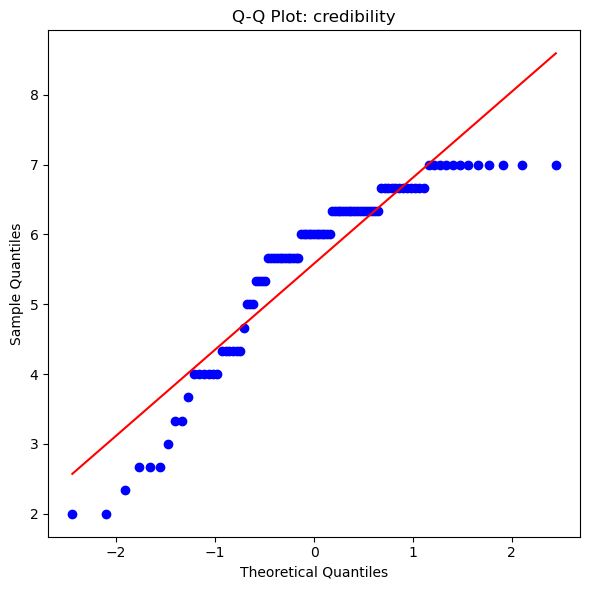

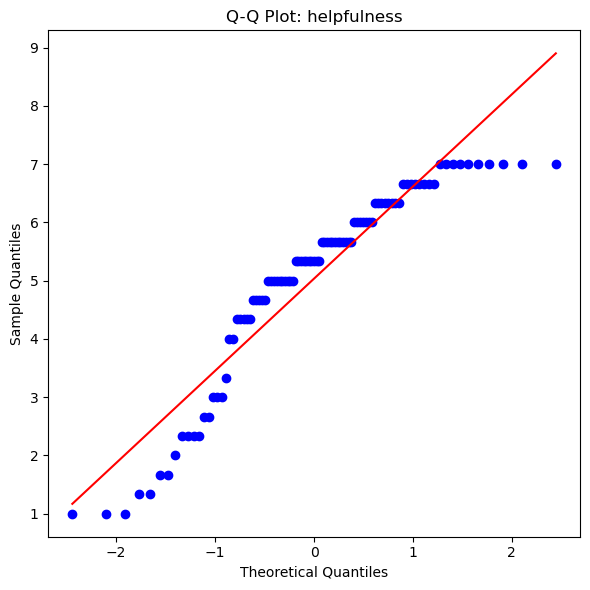

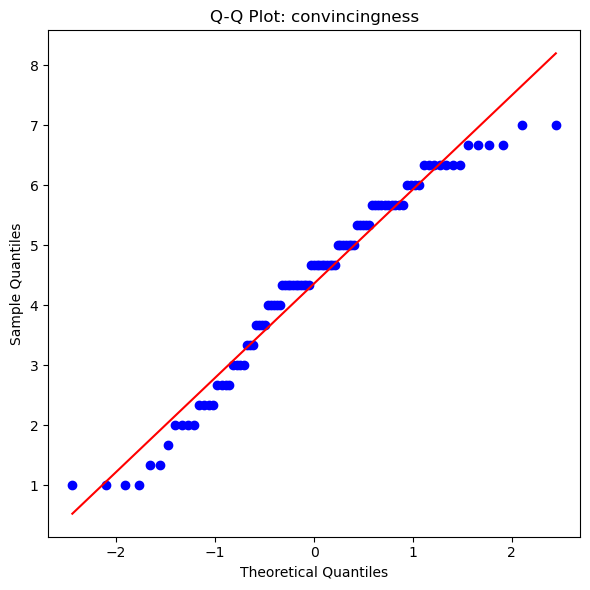

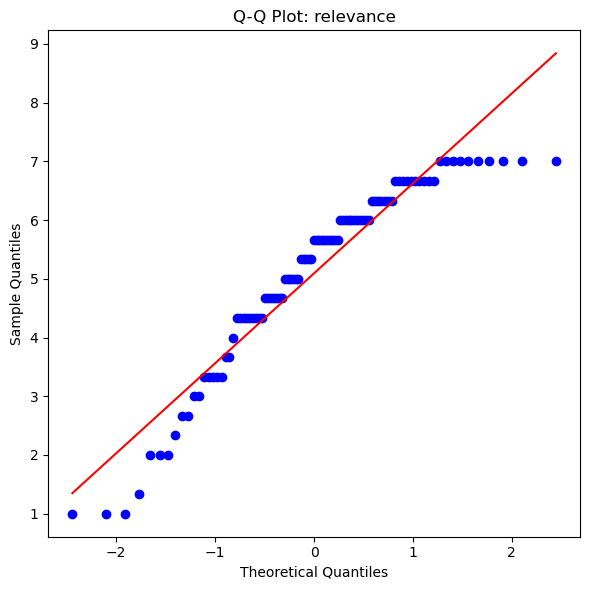

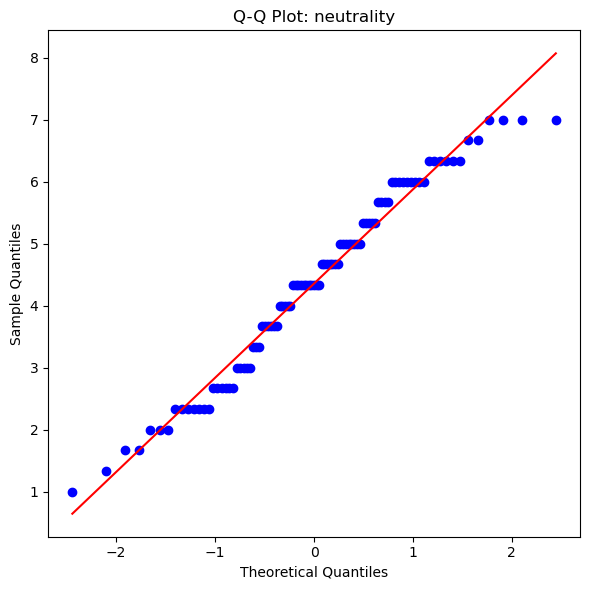

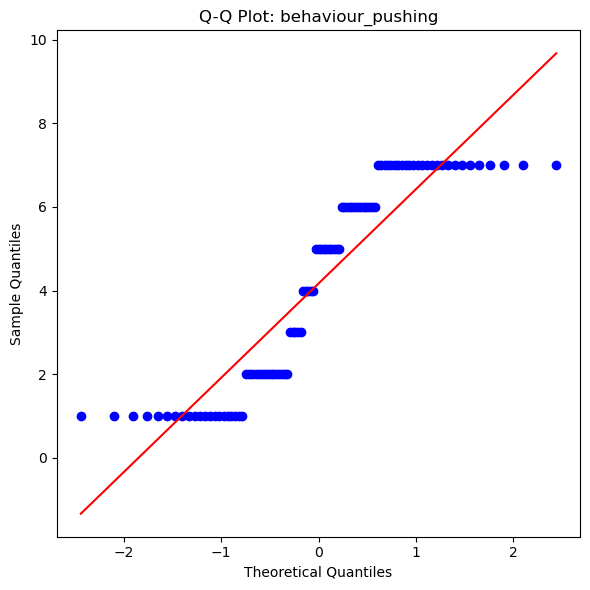

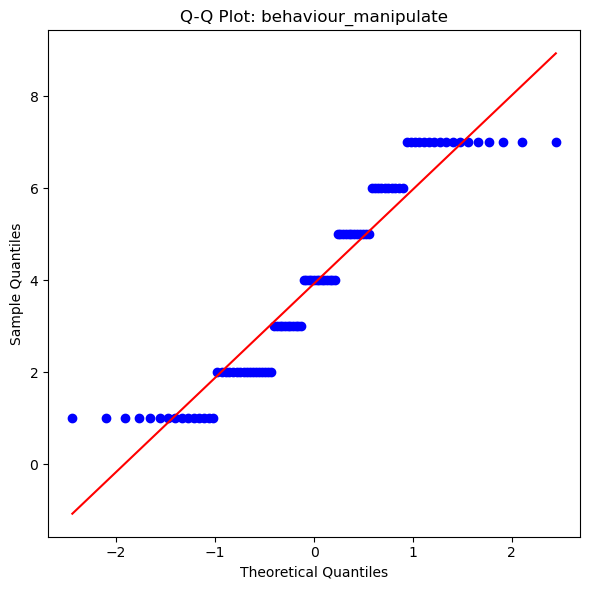

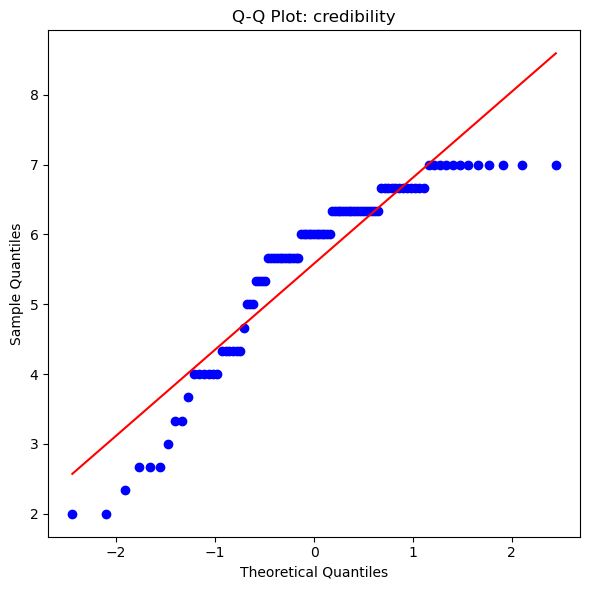

credibility: Shapiro-Wilk W=0.8666, p=0.0000


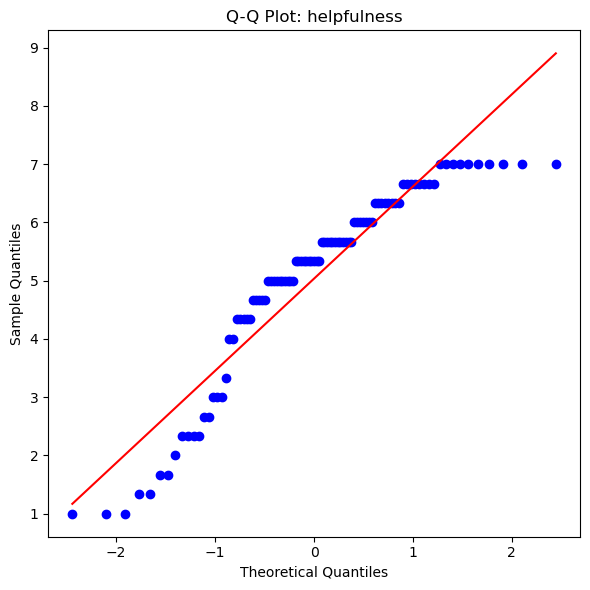

helpfulness: Shapiro-Wilk W=0.8878, p=0.0000


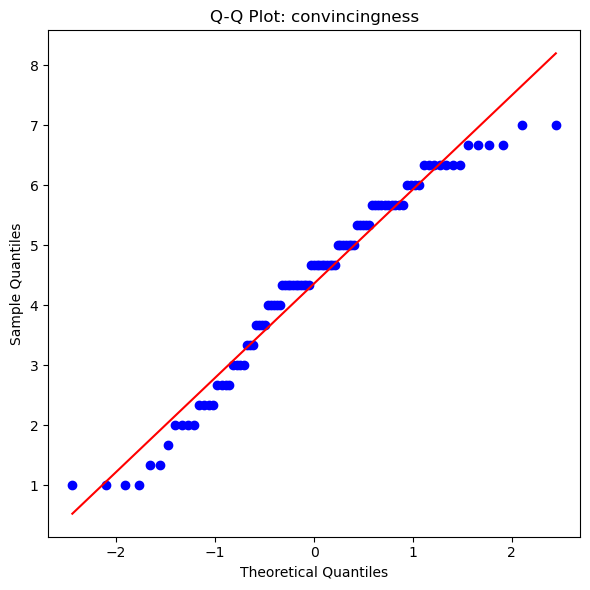

convincingness: Shapiro-Wilk W=0.9570, p=0.0034


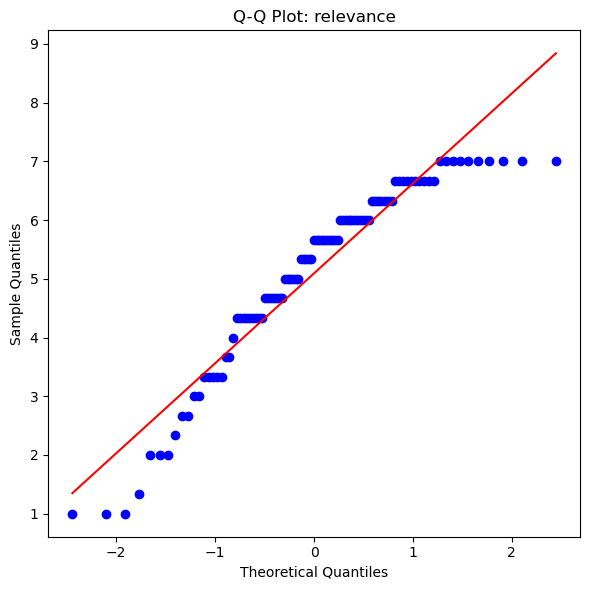

relevance: Shapiro-Wilk W=0.9115, p=0.0000


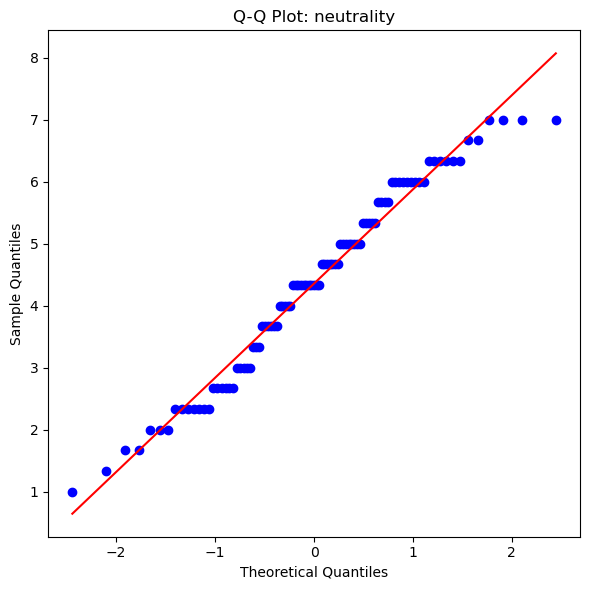

neutrality: Shapiro-Wilk W=0.9700, p=0.0280


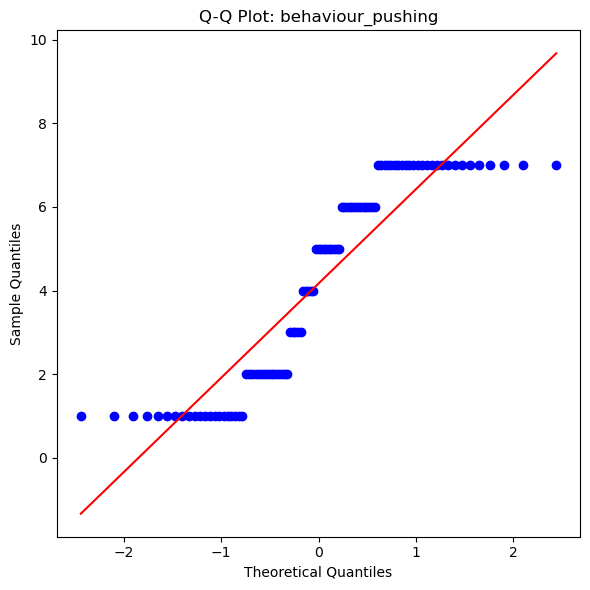

behaviour_pushing: Shapiro-Wilk W=0.8328, p=0.0000


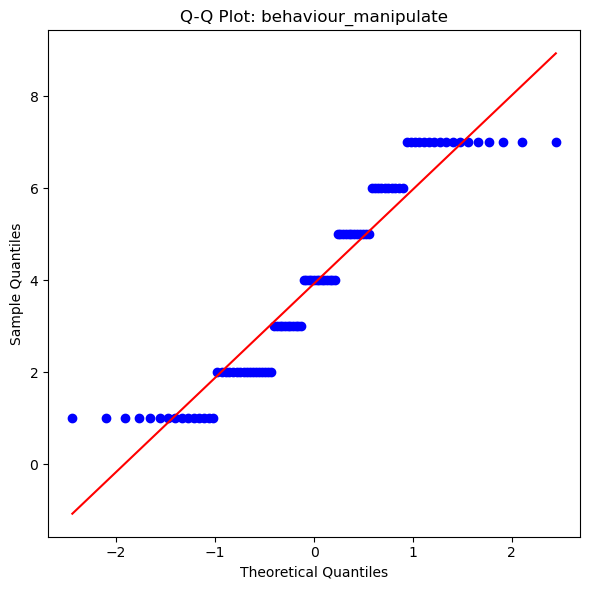

behaviour_manipulate: Shapiro-Wilk W=0.9003, p=0.0000
Q-Q plots and Shapiro-Wilk tests complete.


In [ ]:
# Q-Q plots to inspect normality for each score column in the participant-by-condition CSV.

from pathlib import Path
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
ad_scores_dir = repo_root / "analysis" / "behavioural" / "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)
csv_path = ad_scores_dir / "participant_condition_scores.csv"
df = pd.read_csv(csv_path)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

for col in score_cols:
    if col not in df.columns:
        print(f"Skipping missing column: {col}")
        continue

    values = df[col].dropna().astype(float)
    if values.empty:
        print(f"Skipping {col}: no valid values")
        continue

    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {col}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    plt.tight_layout()
    plt.show()

    shapiro_stat, shapiro_p = stats.shapiro(values)
    print(f"{col}: Shapiro-Wilk W={shapiro_stat:.4f}, p={shapiro_p:.4f}")

print("Q-Q plots and Shapiro-Wilk tests complete.")


In [38]:
# Friedman's test across the 5 conditions for each score.
# Repeated-measures design: the same participant appears in multiple conditions.

from itertools import combinations
from pathlib import Path

import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
ad_scores_dir = repo_root / "analysis" / "behavioural" / "outputs" / "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)
csv_path = ad_scores_dir / "participant_condition_scores.csv"
df = pd.read_csv(csv_path)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

conditions = [
    "block_early",
    "block_late",
    "inline_early",
    "inline_late",
    "no_ads",
]

print("Friedman test across the five conditions")
print("----------------------------------------")

for col in score_cols:
    samples = []
    for cond in conditions:
        s = df.loc[df["condition"] == cond, col].dropna().astype(float)
        if len(s) == 0:
            print(f"{col}: condition {cond} has no data; skipping")
            continue
        samples.append(s.to_numpy())

    if len(samples) != len(conditions):
        print(f"{col}: not all conditions present; using available conditions only")

    if not samples or min(len(s) for s in samples) == 0:
        continue

    stat, p = friedmanchisquare(*samples)
    print(f"{col}: chi2 = {stat:.4f}, p = {p:.6f}")

    pivot = (
        df[["participant_id", "condition", col]]
        .dropna()
        .pivot_table(index="participant_id", columns="condition", values=col, aggfunc="mean")
    )

    pair_results = []
    for cond_a, cond_b in combinations(conditions, 2):
        if cond_a not in pivot.columns or cond_b not in pivot.columns:
            continue

        common = pd.concat([pivot[cond_a], pivot[cond_b]], axis=1).dropna()
        if common.empty:
            continue

        a_vals = common[cond_a].to_numpy(dtype=float)
        b_vals = common[cond_b].to_numpy(dtype=float)

        stat_w, p_w = wilcoxon(a_vals, b_vals, zero_method="wilcox", alternative="two-sided", method="approx")
        pair_results.append({
            "cond_a": cond_a,
            "cond_b": cond_b,
            "n_pairs": len(a_vals),
            "p_raw": float(p_w),
            "w_stat": float(stat_w),
        })

    if not pair_results:
        print(f"  No valid pairwise comparisons for {col}.")
        continue

    pair_results_sorted = sorted(pair_results, key=lambda r: r["p_raw"])
    m = len(pair_results_sorted)
    running_adj = 0.0
    for i, row in enumerate(pair_results_sorted, start=1):
        adj_p = min(1.0, (m - i + 1) * row["p_raw"])
        if i > 1:
            adj_p = min(1.0, max(running_adj, adj_p))
        running_adj = adj_p
        row["p_holm"] = float(adj_p)

    print("  Pairwise Wilcoxon tests (all p-values shown):")
    pair_lookup = {(r["cond_a"], r["cond_b"]): r for r in pair_results}
    for cond_a, cond_b in combinations(conditions, 2):
        row = pair_lookup.get((cond_a, cond_b), pair_lookup.get((cond_b, cond_a)))
        if row is None:
            continue
        print(
            f"    {cond_a} vs {cond_b}: W={row['w_stat']:.4f}, "
            f"p={row['p_raw']:.6f}, Holm-adjusted p={row['p_holm']:.6f}"
        )

print("Finished Friedman tests and Holm-corrected post-hoc comparisons for all five conditions.")


Friedman test across the five conditions
----------------------------------------
credibility: chi2 = 10.1982, p = 0.037218
  Pairwise Wilcoxon tests (all p-values shown):
    block_early vs block_late: W=34.5000, p=0.046175, Holm-adjusted p=0.415572
    block_early vs inline_early: W=57.5000, p=0.586355, Holm-adjusted p=1.000000
    block_early vs inline_late: W=38.5000, p=0.126203, Holm-adjusted p=0.631016
    block_early vs no_ads: W=34.5000, p=0.082097, Holm-adjusted p=0.574677
    block_late vs inline_early: W=9.0000, p=0.003689, Holm-adjusted p=0.036885
    block_late vs inline_late: W=50.5000, p=0.587913, Holm-adjusted p=1.000000
    block_late vs no_ads: W=48.0000, p=0.776706, Holm-adjusted p=1.000000
    inline_early vs inline_late: W=41.5000, p=0.096520, Holm-adjusted p=0.579122
    inline_early vs no_ads: W=22.0000, p=0.054932, Holm-adjusted p=0.439453
    inline_late vs no_ads: W=49.0000, p=0.825626, Holm-adjusted p=1.000000
helpfulness: chi2 = 3.0986, p = 0.541464
  Pairwi

In [37]:
# Create a CSV containing only the significant Friedman omnibus results and the Holm-significant pairwise comparisons.

from itertools import combinations
from pathlib import Path

import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
ad_scores_dir = repo_root / "analysis" / "behavioural" / "outputs"/ "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)

csv_path = ad_scores_dir / "participant_condition_scores.csv"
df = pd.read_csv(csv_path)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

conditions = [
    "block_early",
    "block_late",
    "inline_early",
    "inline_late",
    "no_ads",
]

rows = []

for col in score_cols:
    samples = []
    for cond in conditions:
        s = df.loc[df["condition"] == cond, col].dropna().astype(float)
        if len(s) > 0:
            samples.append(s.to_numpy())

    if len(samples) != len(conditions):
        continue

    stat, p = friedmanchisquare(*samples)
    if p < 0.05:
        rows.append(
            {
                "analysis_type": "friedman",
                "score": col,
                "condition_set": "block_early, block_late, inline_early, inline_late, no_ads",
                "statistic": float(stat),
                "p_value": float(p),
                "holm_adjusted_p": None,
                "condition_pair": None,
            }
        )

    pivot = (
        df[["participant_id", "condition", col]]
        .dropna()
        .pivot_table(index="participant_id", columns="condition", values=col, aggfunc="mean")
    )

    pair_records = []
    for cond_a, cond_b in combinations(conditions, 2):
        if cond_a not in pivot.columns or cond_b not in pivot.columns:
            continue

        common = pd.concat([pivot[cond_a], pivot[cond_b]], axis=1).dropna()
        if common.empty:
            continue

        a_vals = common[cond_a].to_numpy(dtype=float)
        b_vals = common[cond_b].to_numpy(dtype=float)

        _, p_raw = wilcoxon(a_vals, b_vals, zero_method="wilcox", alternative="two-sided", method="approx")
        pair_records.append((cond_a, cond_b, float(p_raw)))

    if not pair_records:
        continue

    pair_records_sorted = sorted(pair_records, key=lambda x: x[2])
    m = len(pair_records_sorted)
    running_adj = 0.0
    for i, (cond_a, cond_b, p_raw) in enumerate(pair_records_sorted, start=1):
        adj_p = min(1.0, (m - i + 1) * p_raw)
        if i > 1:
            adj_p = min(1.0, max(running_adj, adj_p))
        running_adj = adj_p

        if adj_p < 0.05:
            rows.append(
                {
                    "analysis_type": "wilcoxon_holm",
                    "score": col,
                    "condition_set": None,
                    "statistic": None,
                    "p_value": float(p_raw),
                    "holm_adjusted_p": float(adj_p),
                    "condition_pair": f"{cond_a} vs {cond_b}",
                }
            )

out_path = ad_scores_dir / "significant_friedman_holm_results.csv"
output = pd.DataFrame(rows)
if not output.empty:
    output = output[
        [
            "analysis_type",
            "score",
            "condition_set",
            "condition_pair",
            "statistic",
            "p_value",
            "holm_adjusted_p",
        ]
    ]

output.to_csv(out_path, index=False)
print(f"Saved {len(output)} significant rows to {out_path}")
print(output.to_string(index=False))


Saved 4 significant rows to C:\Users\katly\Documents\GitHub\MasterThesis-The-Price-of-Attention\analysis\behavioural\outputs\ad_scores\significant_friedman_holm_results.csv
analysis_type             score                                              condition_set             condition_pair  statistic  p_value  holm_adjusted_p
     friedman       credibility block_early, block_late, inline_early, inline_late, no_ads                       None  10.198198 0.037218              NaN
wilcoxon_holm       credibility                                                       None block_late vs inline_early        NaN 0.003689         0.036885
     friedman behaviour_pushing block_early, block_late, inline_early, inline_late, no_ads                       None  10.570571 0.031839              NaN
wilcoxon_holm behaviour_pushing                                                       None      block_early vs no_ads        NaN 0.001896         0.018960


In [40]:
# Friedman test with Benjamini-Hochberg FDR correction for all pairwise comparisons.
# This is an independent analysis cell; it does not modify the earlier cells.

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon


def find_project_root(start: Path) -> Path:
    seen = set()
    for candidate in [start.resolve(), *start.resolve().parents]:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "src" / "project" / "logs" / "tracked" / "lab").exists():
            return candidate
    return start.resolve()


repo_root = find_project_root(Path.cwd())
ad_scores_dir = repo_root / "analysis" / "behavioural" / "outputs" / "ad_scores"
ad_scores_dir.mkdir(parents=True, exist_ok=True)
csv_path = ad_scores_dir / "participant_condition_scores.csv"
df = pd.read_csv(csv_path)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

conditions = [
    "block_early",
    "block_late",
    "inline_early",
    "inline_late",
    "no_ads",
]

print("Friedman + Benjamini-Hochberg FDR analysis")
print("----------------------------------------")

significant_lines = []
for col in score_cols:
    samples = []
    for cond in conditions:
        s = df.loc[df["condition"] == cond, col].dropna().astype(float)
        if len(s) == 0:
            continue
        samples.append(s.to_numpy())

    if len(samples) != len(conditions):
        print(f"{col}: skipped because not all 5 conditions are available.")
        continue

    f_stat, f_p = friedmanchisquare(*samples)
    print(f"{col}: Friedman chi2={f_stat:.4f}, p={f_p:.6f}")
    if f_p < 0.05:
        significant_lines.append(f"OMNIBUS SIGNIFICANT: {col} | chi2={f_stat:.4f} | p={f_p:.6f}")

    pivot = (
        df[["participant_id", "condition", col]]
        .dropna()
        .pivot_table(index="participant_id", columns="condition", values=col, aggfunc="mean")
    )

    pair_records = []
    for cond_a, cond_b in combinations(conditions, 2):
        if cond_a not in pivot.columns or cond_b not in pivot.columns:
            continue

        common = pd.concat([pivot[cond_a], pivot[cond_b]], axis=1).dropna()
        if common.empty:
            continue

        a_vals = common[cond_a].to_numpy(dtype=float)
        b_vals = common[cond_b].to_numpy(dtype=float)

        _, p_raw = wilcoxon(a_vals, b_vals, zero_method="wilcox", alternative="two-sided", method="approx")
        pair_records.append({
            "cond_a": cond_a,
            "cond_b": cond_b,
            "p_raw": float(p_raw),
        })

    if not pair_records:
        continue

    pair_df = pd.DataFrame(pair_records)
    pair_df = pair_df.sort_values("p_raw", ascending=True, ignore_index=True)
    pair_df["rank"] = np.arange(1, len(pair_df) + 1)
    pair_df["bh_q"] = pair_df["p_raw"] * len(pair_df) / pair_df["rank"]

    for i in range(len(pair_df) - 2, -1, -1):
        pair_df.at[i, "bh_q"] = min(pair_df.at[i, "bh_q"], pair_df.at[i + 1, "bh_q"])
    pair_df["bh_q"] = pair_df["bh_q"].clip(upper=1.0)

    print(f"  Pairwise Wilcoxon + BH-FDR for {col}:")
    for _, row in pair_df.iterrows():
        print(
            f"    {row['cond_a']} vs {row['cond_b']}: "
            f"p={row['p_raw']:.6f}, BH-FDR q={row['bh_q']:.6f}"
        )
        if row["bh_q"] < 0.05:
            significant_lines.append(
                f"PAIRWISE SIGNIFICANT: {col} | {row['cond_a']} vs {row['cond_b']} | "
                f"p={row['p_raw']:.6f} | BH-q={row['bh_q']:.6f}"
            )

print("\nSummary of significant findings:")
if significant_lines:
    for line in significant_lines:
        print(line)
else:
    print("No significant findings after BH-FDR correction.")

print("\nDone.")


Friedman + Benjamini-Hochberg FDR analysis
----------------------------------------
credibility: Friedman chi2=10.1982, p=0.037218
  Pairwise Wilcoxon + BH-FDR for credibility:
    block_late vs inline_early: p=0.003689, BH-FDR q=0.036885
    block_early vs block_late: p=0.046175, BH-FDR q=0.183106
    inline_early vs no_ads: p=0.054932, BH-FDR q=0.183106
    block_early vs no_ads: p=0.082097, BH-FDR q=0.193041
    inline_early vs inline_late: p=0.096520, BH-FDR q=0.193041
    block_early vs inline_late: p=0.126203, BH-FDR q=0.210339
    block_early vs inline_early: p=0.586355, BH-FDR q=0.734891
    block_late vs inline_late: p=0.587913, BH-FDR q=0.734891
    block_late vs no_ads: p=0.776706, BH-FDR q=0.825626
    inline_late vs no_ads: p=0.825626, BH-FDR q=0.825626
helpfulness: Friedman chi2=3.0986, p=0.541464
  Pairwise Wilcoxon + BH-FDR for helpfulness:
    block_early vs inline_late: p=0.075007, BH-FDR q=0.462010
    inline_early vs inline_late: p=0.092402, BH-FDR q=0.462010
    bl